In [1]:
import re
from pathlib import Path
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
from shapesimilarity import shape_similarity
from scipy.spatial import procrustes
from scipy.spatial.distance import pdist
from scipy.spatial.distance import cdist

# Setup

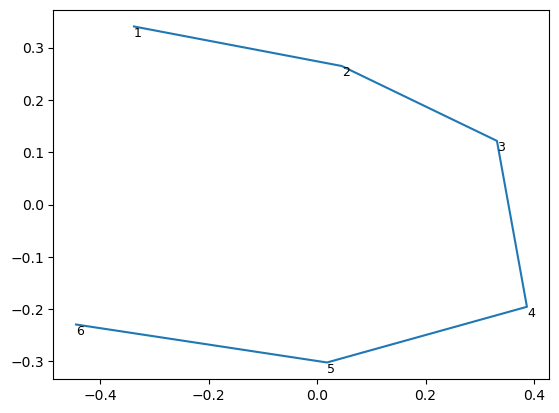

In [2]:
################################
#reference shape (local)
################################

# ref_ts = np.array([1, 2, 3, 4, 5, 6])
ref_ts=np.array([6,5,4,3,2,1])
ref_order = np.argsort(ref_ts)

#from data
# x_compare=[-0.337638,0.045318,0.331642,0.386951,0.018275,-0.444548]
# y_compare =[-0.340506,-0.264926,-0.121715,0.195594,0.302092,0.229461]
#from data
x_compare = [-0.444548, 0.018275, 0.386951, 0.331642, 0.045318, -0.337638]
y_compare = [-0.229461, -0.302092, -0.195594, 0.121715, 0.264926, 0.340506]

xs_ref = np.array(x_compare)[ref_order]
ys_ref = np.array(y_compare)[ref_order]
ref_ts_sort=np.array(ref_ts)[ref_order]
reference_hex= list(zip(xs_ref, ys_ref))

plt.plot(
    xs_ref,
    ys_ref
)
for t, x, y in zip(ref_ts_sort, xs_ref, ys_ref):
    plt.text(x, y, str(t), fontsize=9, ha="left", va="top")

In [3]:
reference_hex = np.column_stack([xs_ref, ys_ref])

# flipped reference
reference_hex_flipped = reference_hex.copy()
reference_hex_flipped[:, 1] *= -1

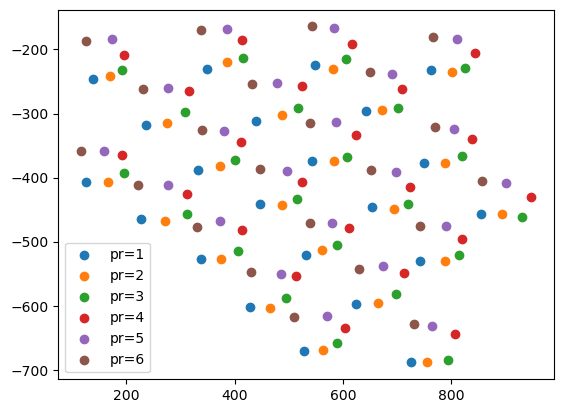

In [4]:
data=pd.read_csv("lamina2 (1).csv",header=None)

x=data[0]
y=data[1]
data[2]=arr = np.repeat(np.arange(1, 23), 6)
data[3] = np.tile(np.arange(6, 0, -1), 22)


data[4]=data[2].astype(str)


# groups = np.asarray(data[2])   #only for discrete colouring
# 
# for g in np.unique(groups):
#     mask = groups == g
#     plt.scatter(x[mask],y[mask])
#     plt.plot( x[mask],y[mask])
# plt.show()

groups = np.asarray(data[3])   

for g in np.unique(groups):
    mask = groups == g
    plt.scatter( x[mask], -y[mask], label=f"pr={g}")


plt.legend()
plt.show()

In [5]:
shapes=[]

for i in range(1, 23):

    shape1=data[data[2]==i]
    shape1 = shape1.sort_values(by=3)
    shapes.append(shape1)

# Mean shape dissim for bio data

In [6]:
similarities = []
dissim = []
bundle_centers = []

ref = np.array(reference_hex)

for bundle_id, shape in enumerate(shapes, start=1):

    #x-y per bundle
    model = shape[[0, 1]].to_numpy(dtype=float)

    #if i have cells
    if len(model) > 0:
        center = np.mean(model, axis=0)
        bundle_centers.append(center)

    #local
    ref_aligned, model_aligned, disparity = procrustes(ref, model)
    sim = shape_similarity(ref_aligned, model_aligned)

    dissim.append(disparity)
    similarities.append(sim)

# local run metrics
local_metric = np.nanmean(dissim)
local_metric_sd = np.nanstd(dissim)

local_similarity = np.nanmean(similarities)
local_similarity_sd = np.nanstd(similarities)



print("\n-->Bio metric")
print("local dissimilarity mean:", local_metric)
print("local dissimilarity sd:  ", local_metric_sd)
print("local simmilarity mean:", local_similarity)


-->Bio metric
local dissimilarity mean: 0.014635992594652175
local dissimilarity sd:   0.008327479826503838
local simmilarity mean: 0.9454363636363635


# Check global grid for example Unity-PDE-endstate, PDE and raw Unity

In [7]:
normal_bio = pd.read_csv("bundle_centers_bio.csv")
normal_bio_fl=normal_bio.copy()


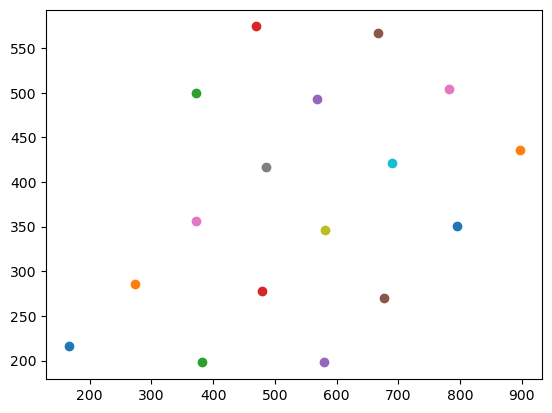

In [8]:

for b in sorted(normal_bio["bundle"].unique()):
    g = normal_bio[normal_bio["bundle"] == b]

    plt.scatter(g["x"], g["y"])

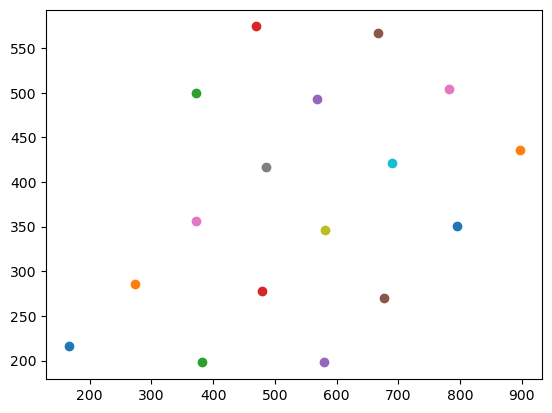

In [9]:

y_center = normal_bio_fl["y"].mean()
normal_bio_fl["y_flip"] =  - normal_bio_fl["y"]



for b in sorted(normal_bio_fl["bundle"].unique()):
    g = normal_bio_fl[normal_bio_fl["bundle"] == b]
    plt.scatter(g["x"], g["y"])


In [10]:
bundle_centers_unity = pd.read_csv("bundle_centers_unityt.csv")
#only for sim data. delete last
bundle_centers_unity = bundle_centers_unity.iloc[:-1].copy()
bundle_centersu = bundle_centers_unity[["x", "y"]].to_numpy()

#bio data
bundle_cs_f = normal_bio_fl[["x", "y_flip"]].to_numpy()
bundle_cs =normal_bio[["x", "y"]].to_numpy()

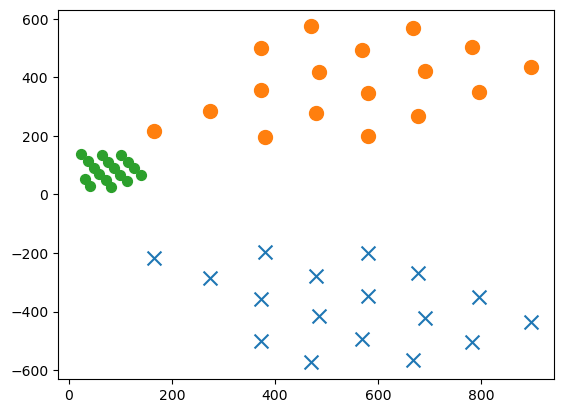

In [11]:
plt.scatter(bundle_cs_f[:, 0], bundle_cs_f[:, 1], marker="x",s=100,label="bundle centers")
plt.scatter(bundle_cs[:, 0],bundle_cs[:, 1],marker="o", s=100,label="bundle centers")
plt.scatter( bundle_centersu[:, 0], bundle_centersu[:, 1], marker="o",s=50,label="bundle centers U")


dissim:  9.458723439371812e-32


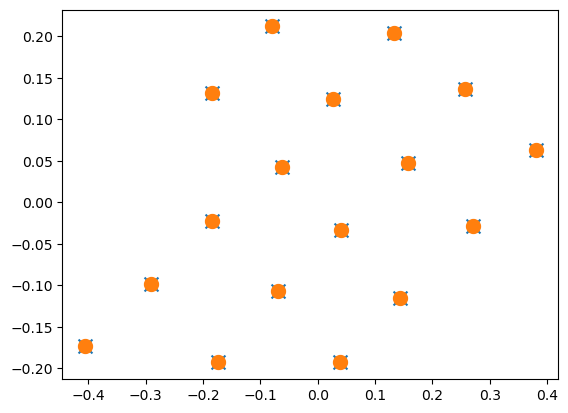

In [12]:
#check bio-bio-flip
bio,bio_fl,dissim = procrustes(bundle_cs, bundle_cs_f)


plt.scatter( bio[:, 0],bio[:, 1],marker="x",s=100, label="bundle centers")
plt.scatter( bio_fl[:, 0],bio_fl[:, 1], marker="o", s=100,label="bundle centers")
print("dissim: ",dissim)
#better to flip?

dissim:  0.06932081651442303


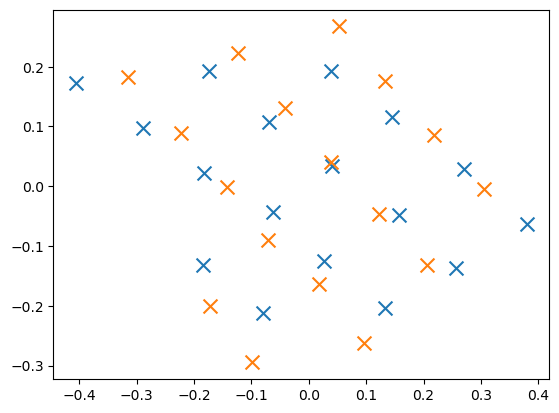

In [13]:
bio,unity,dissim = procrustes(bundle_cs_f, bundle_centersu)


plt.scatter(bio[:, 0],bio[:, 1], marker="x", s=100, label="bundle centers")
plt.scatter(unity[:, 0], unity[:, 1],marker="x",s=100, label="bundle centers U")
print("dissim: ",dissim)
# non- flip 0.06932081651442311

In [14]:
#check global metric

from scipy.spatial import KDTree
import numpy as np


tree = KDTree(np.c_[bio[:, 0], bio[:, 1]])
distances, _ = tree.query(np.c_[unity[:, 0],unity[:, 1]], k=1)  # distance to nearest point in (Xdata, Ydata) 
print(np.mean(distances))


0.05692003452817227


In [15]:
#tree = KDTree(np.c_[bio[:, 0],bio[:, 1]])
distances, _ = tree.query(np.c_[bio[:, 0],bio[:, 1]], k=1)  # distance to nearest point in (Xdata, Ydata) 
print(np.mean(distances))

0.0


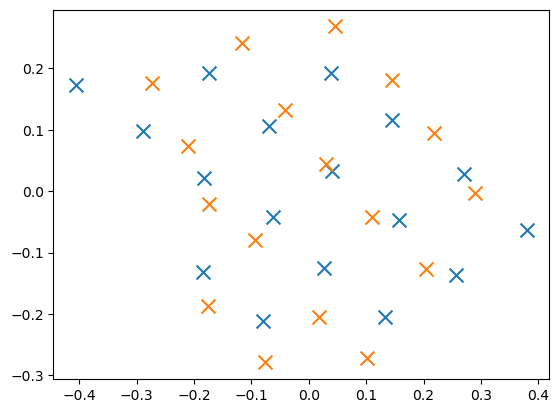

In [16]:
bundle_centers_pde = pd.read_csv("bundle_centers_pde.csv")
bundle_centers_pde = bundle_centers_pde.iloc[:-1].copy()
bundle_centersp = bundle_centers_pde[["x", "y"]].to_numpy()


bio, pde, dissim = procrustes(bundle_cs_f, bundle_centersp)

plt.scatter(bio[:, 0], bio[:, 1], marker="x", s=100,label="bundle centers")
plt.scatter( pde[:, 0], pde[:, 1], marker="x",s=100,label="bundle centers PDE")

In [17]:
# tree = KDTree(np.c_[pde[:, 0], pde[:, 1]])
distances, _ = tree.query(np.c_[pde[:, 0],pde[:, 1]], k=1)  # distance to nearest point in (Xdata, Ydata) 
np.mean(distances)

np.float64(0.058472305286090855)

# Other ref

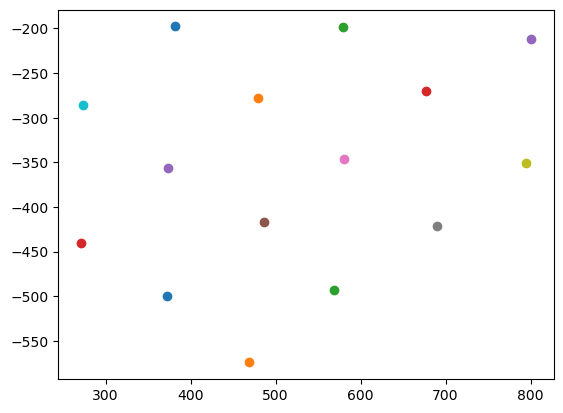

In [18]:
normal_bio = pd.read_csv("bundle_centers_bio2.csv")
normal_bio_fl = normal_bio.copy()
normal_bio_fl

for b in sorted(normal_bio["bundle"].unique()):
    g = normal_bio[normal_bio["bundle"] == b]

    plt.scatter(
        g["x"],
        g["y"],
        label=f"bundle={b}"
    )

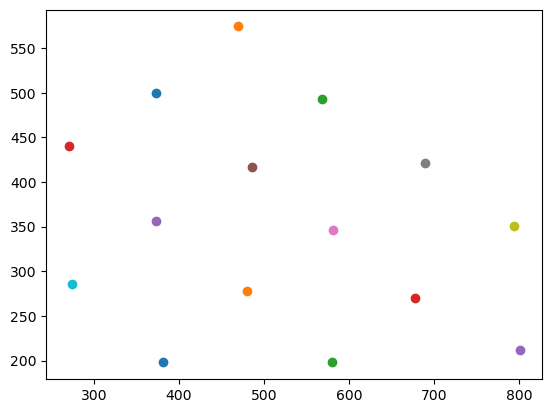

In [19]:

y_center = normal_bio_fl["y"].mean()
normal_bio_fl["y_flip"] = - normal_bio_fl["y"]

for b in sorted(normal_bio_fl["bundle"].unique()):
    g = normal_bio_fl[normal_bio_fl["bundle"] == b]

    plt.scatter(
        g["x"],
        g["y_flip"],
        label=f"bundle={b}"
    )

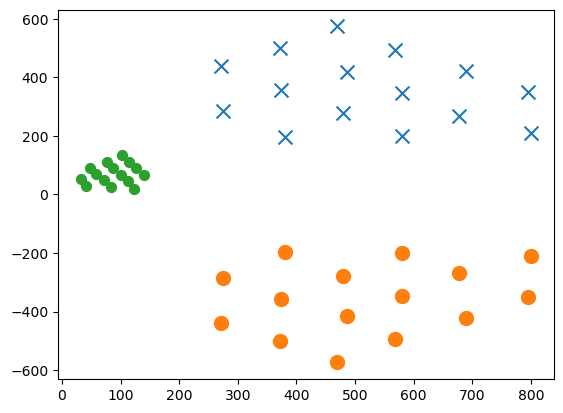

In [20]:

bundle_centers_unity = pd.read_csv("bundle_centers_unityt.csv")
#only for sim data2 . delete first 3
bundle_centers_unity = bundle_centers_unity.iloc[3:].copy()
bundle_centersu = bundle_centers_unity[["x", "y"]].to_numpy()

#bio data
bundle_cs_f = normal_bio_fl[["x", "y_flip"]].to_numpy()
bundle_cs = normal_bio[["x", "y"]].to_numpy()
plt.scatter(bundle_cs_f[:, 0], bundle_cs_f[:, 1], marker="x",s=100,label="bundle centers")
plt.scatter(bundle_cs[:, 0],bundle_cs[:, 1],marker="o", s=100,label="bundle centers")
plt.scatter( bundle_centersu[:, 0], bundle_centersu[:, 1], marker="o",s=50,label="bundle centers U")



0.06566337962482204
0.06868809457049951
0.06717573709766078


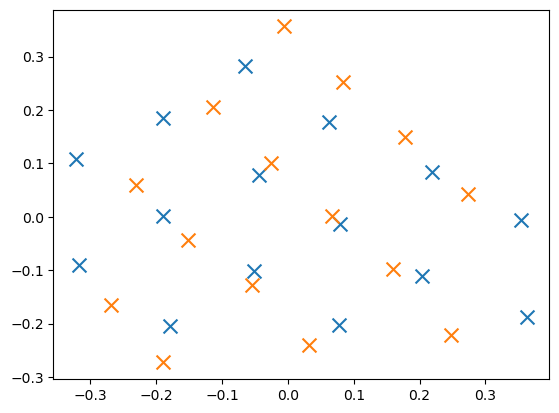

In [21]:

bio,unity,dissim = procrustes(bundle_cs_f, bundle_centersu)

plt.scatter(bio[:, 0], bio[:, 1], marker="x", s=100,label="bundle centers")
plt.scatter( unity[:, 0], unity[:, 1], marker="x",s=100,label="bundle centers Unity")

tree = KDTree(np.c_[bio[:, 0], bio[:, 1]])
distances1, _ = tree.query(np.c_[unity[:, 0], unity[:, 1]], k=1)
tree = KDTree(np.c_[unity[:, 0], unity[:, 1]])
distances2, _ = tree.query(np.c_[bio[:, 0], bio[:, 1]], k=1) # distance to nearest point in (Xdata, Ydata) 
print(np.mean(distances1))
print(np.mean(distances2))
print((np.mean(distances1)+np.mean(distances2))/2)

In [22]:

tree = KDTree(np.c_[bio[:, 0],bio[:, 1]])
distances, _ = tree.query(np.c_[bio[:, 0], bio[:, 1]], k=1)  # distance to nearest point in (Xdata, Ydata) 
print(np.mean(distances))

0.0


0.06478893843477282
0.0711958000261476
0.0679923692304602


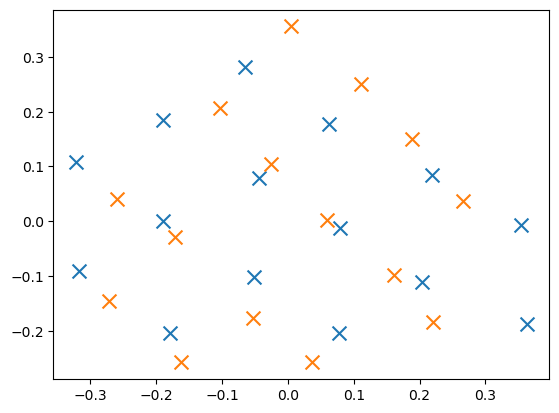

In [23]:
bundle_centers_pde = pd.read_csv("bundle_centers_pde.csv")
bundle_centers_pde = bundle_centers_pde.iloc[3:].copy()
bundle_centersp = bundle_centers_pde[["x", "y"]].to_numpy()

bio, pde, dissim = procrustes(bundle_cs_f, bundle_centersp)


plt.scatter(bio[:, 0], bio[:, 1], marker="x", s=100,label="bundle centers")
plt.scatter( pde[:, 0], pde[:, 1], marker="x",s=100,label="bundle centers PDE")

tree = KDTree(np.c_[bio[:, 0], bio[:, 1]])
distances1, _ = tree.query(np.c_[pde[:, 0], pde[:, 1]], k=1)
tree = KDTree(np.c_[pde[:, 0], pde[:, 1]])
distances2, _ = tree.query(np.c_[bio[:, 0], bio[:, 1]], k=1) # distance to nearest point in (Xdata, Ydata) 
print(np.mean(distances1))
print(np.mean(distances2))
print((np.mean(distances1)+np.mean(distances2))/2)

# RAw Unity


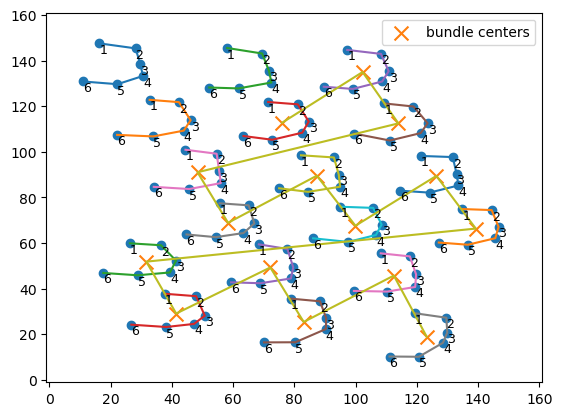

local dissim: 0.0716696020439239
global dissim: 0.06819470607942285
local dissim sd: 0.023415653816377984


In [26]:
import tarfile

def get_cell_type_TS(cell_id):
    p = cell_id // 2
    part = cell_id % 2  # 0=.re, 1=.im

    if p % 3 == 0:
        return 5 if part == 0 else 2
    elif p % 3 == 1:
        return 4 if part == 0 else 3
    else:
        return 6 if part == 0 else 1
# FRAMES_DIR = Path( r"E:\MASTER THESIS\code\out_debug_ver2b_576_3_6_15_2_2_1.5")
#TAR_PATH = Path(r"E:\MASTER THESIS\code\ver2b sweeps\D-27\out_debug_ver2b_adh27_D_16_3_6_5_2_7_0.21899544273840021.tar.gz")
TAR_PATH= Path(r"E:\MASTER THESIS\code\unity sweep\Drep5\out_debug_unity_D-rep5_17_3_6_5_2_2_0.2133351221567175.tar.gz")
end_frame = 0
NX = 512
dx = 0.3125

PATTERN_RHO = re.compile(r"rho(\d+)-t([0-9.eE+-]+)\.txt")

y, x = np.indices((NX, NX))
x_scaled = x * dx
y_scaled = y * dx

xs = []
ys = []
ts = []
bs = []


################################
#for tar file
################################
with tarfile.open(TAR_PATH, "r:gz") as tar:

    cells = [
        member for member in tar.getmembers()
        if member.isfile()
        and Path(member.name).name.startswith("rho")
        and Path(member.name).name.endswith(f"-t{end_frame}.txt")
    ]

    ################################
    # for every cell field
    ################################
    for cell in cells:

        fname = Path(cell.name).name

        m = re.search(PATTERN_RHO, fname)
        if not m:
            continue

        f = tar.extractfile(cell)
        rho = np.loadtxt(f)
        total_mass = np.sum(rho)

        if total_mass == 0 or not np.isfinite(total_mass):
            continue

        x_cm = np.sum(x_scaled * rho) / total_mass
        y_cm = np.sum(y_scaled * rho) / total_mass

        cell_id = int(m.group(1))

        xs.append(x_cm)
        ys.append(y_cm)
        ts.append(get_cell_type_TS(cell_id))
        bs.append(cell_id // 6)

################################
# all cell data is loaded
################################
xs = np.array(xs)
ys = np.array(ys)
ts = np.array(ts)
bs = np.array(bs)

selected_bundles = {3, 7, 8, 9, 14, 16}
bundle_centers = []
dissim = []
bundle_ids = []

plt.scatter(xs, ys)

################################
# for every bundle
################################
for bundle in sorted(set(bs)):
    # if bundle not in selected_bundles:
    #     continue
    mask = bs == bundle

    xs_b = xs[mask]
    ys_b = ys[mask]
    ts_b = ts[mask]

    order = np.argsort(ts_b)

    xs_sorted = xs_b[order]
    ys_sorted = ys_b[order]
    ts_sorted = ts_b[order]

    figure_bundle = list(zip(xs_sorted, ys_sorted))
    model = np.array(figure_bundle)

    # Plot cells and bundle shape
    for t, x_pos, y_pos in zip(ts_sorted, xs_sorted, ys_sorted):
        plt.text(x_pos, y_pos,str(t),fontsize=9,ha="left",va="top")

    plt.plot(xs_sorted, ys_sorted)

    #skip broken bundles
    if (model.shape != ref.shape or not np.isfinite(model).all() or len(np.unique(model, axis=0)) != 6):
        dissim.append(np.nan)
        continue

    # Local metric
    ref_aligned, model_aligned, disparity = procrustes(ref, model)
    dissim.append(disparity)

    bundle_ids.append(bundle)
    bundle_centers.append([ np.mean(xs_b), np.mean(ys_b)])

################################
# global metric
################################
bundle_centers = np.array(bundle_centers)

# Remove  bundle if required for this grid
bundle_centers = bundle_centers[3:].copy()

if bundle_centers.shape == bundle_cs_f.shape:

        run, bio_fl, _ = procrustes(bundle_centers, bundle_cs_f)
        
        tree = KDTree(np.c_[bio_fl[:, 0], bio_fl[:, 1]])
        distances1, _ = tree.query(np.c_[run[:, 0],run[:, 1]], k=1) 
        
        tree = KDTree(np.c_[run[:, 0], run[:, 1]])
        distances2, _ = tree.query(np.c_[bio_fl[:, 0],bio_fl[:, 1]], k=1) 
        all_distances = np.concatenate([distances1, distances2])
        global_dissim= np.mean(all_distances)
        global_dissim_sd= np.std(all_distances)

else:
    global_dissim = np.nan
    global_dissim_sd = np.nan

################################
# plot
################################
plt.scatter(bundle_centers[:, 0],bundle_centers[:, 1],marker="x", s=100, label="bundle centers")
plt.plot( bundle_centers[:, 0], bundle_centers[:, 1])

plt.xlim(-1, NX*dx + 1)
plt.ylim(-1, NX*dx + 1)

plt.legend()
plt.show()

print("local dissim:", np.nanmean(dissim))
print("global dissim:", global_dissim)
print("local dissim sd:", np.nanstd(dissim))

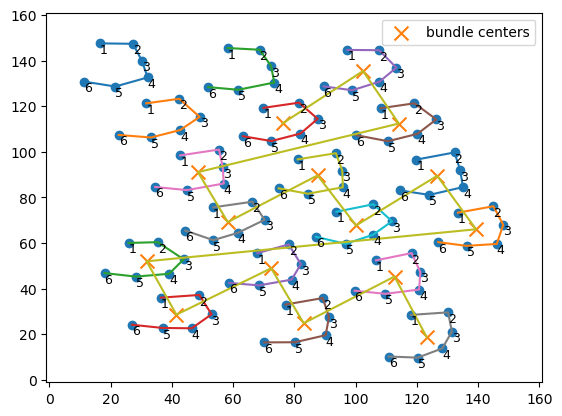

local dissim: 0.08636910750006341
global dissim: 0.0683891444617744
local dissim sd: 0.027682706763049864


In [27]:
end_frame = 45
NX = 512
dx = 0.3125

PATTERN_RHO = re.compile(r"rho(\d+)-t([0-9.eE+-]+)\.txt")

y, x = np.indices((NX, NX))
x_scaled = x * dx
y_scaled = y * dx

xs = []
ys = []
ts = []
bs = []


################################
#for tar file
################################
with tarfile.open(TAR_PATH, "r:gz") as tar:

    cells = [
        member for member in tar.getmembers()
        if member.isfile()
        and Path(member.name).name.startswith("rho")
        and Path(member.name).name.endswith(f"-t{end_frame}.txt")
    ]

    ################################
    # for every cell field
    ################################
    for cell in cells:

        fname = Path(cell.name).name

        m = re.search(PATTERN_RHO, fname)
        if not m:
            continue

        f = tar.extractfile(cell)
        rho = np.loadtxt(f)
        total_mass = np.sum(rho)

        if total_mass == 0 or not np.isfinite(total_mass):
            continue

        x_cm = np.sum(x_scaled * rho) / total_mass
        y_cm = np.sum(y_scaled * rho) / total_mass

        cell_id = int(m.group(1))

        xs.append(x_cm)
        ys.append(y_cm)
        ts.append(get_cell_type_TS(cell_id))
        bs.append(cell_id // 6)

################################
# all cell data is loaded
################################
xs = np.array(xs)
ys = np.array(ys)
ts = np.array(ts)
bs = np.array(bs)

selected_bundles = {3, 7, 8, 9, 14, 16}
bundle_centers = []
dissim = []
bundle_ids = []

plt.scatter(xs, ys)

################################
# for every bundle
################################
for bundle in sorted(set(bs)):
    # if bundle not in selected_bundles:
    #     continue
    mask = bs == bundle

    xs_b = xs[mask]
    ys_b = ys[mask]
    ts_b = ts[mask]

    order = np.argsort(ts_b)

    xs_sorted = xs_b[order]
    ys_sorted = ys_b[order]
    ts_sorted = ts_b[order]

    figure_bundle = list(zip(xs_sorted, ys_sorted))
    model = np.array(figure_bundle)

    # Plot cells and bundle shape
    for t, x_pos, y_pos in zip(ts_sorted, xs_sorted, ys_sorted):
        plt.text(x_pos, y_pos,str(t),fontsize=9,ha="left",va="top")

    plt.plot(xs_sorted, ys_sorted)

    #skip broken bundles
    if (model.shape != ref.shape or not np.isfinite(model).all() or len(np.unique(model, axis=0)) != 6):
        dissim.append(np.nan)
        continue

    # Local metric
    ref_aligned, model_aligned, disparity = procrustes(ref, model)
    dissim.append(disparity)

    bundle_ids.append(bundle)
    bundle_centers.append([ np.mean(xs_b), np.mean(ys_b)])

################################
# global metric
################################
bundle_centers = np.array(bundle_centers)

# Remove  bundle if required for this grid
bundle_centers = bundle_centers[3:].copy()

if bundle_centers.shape == bundle_cs_f.shape:

        run, bio_fl, _ = procrustes(bundle_centers, bundle_cs_f)
        
        tree = KDTree(np.c_[bio_fl[:, 0], bio_fl[:, 1]])
        distances1, _ = tree.query(np.c_[run[:, 0],run[:, 1]], k=1) 
        
        tree = KDTree(np.c_[run[:, 0], run[:, 1]])
        distances2, _ = tree.query(np.c_[bio_fl[:, 0],bio_fl[:, 1]], k=1) 
        all_distances = np.concatenate([distances1, distances2])
        global_dissim= np.mean(all_distances)
        global_dissim_sd= np.std(all_distances)

else:
    global_dissim = np.nan
    global_dissim_sd = np.nan

################################
# plot
################################
plt.scatter(bundle_centers[:, 0],bundle_centers[:, 1],marker="x", s=100, label="bundle centers")
plt.plot( bundle_centers[:, 0], bundle_centers[:, 1])

plt.xlim(-1, NX*dx + 1)
plt.ylim(-1, NX*dx + 1)

plt.legend()
plt.show()

print("local dissim:", np.nanmean(dissim))
print("global dissim:", global_dissim)
print("local dissim sd:", np.nanstd(dissim))